# Tennis Betting Model

## Load and Clean Data

### Import Libraries

In [755]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

### Load Match Data

In [756]:
def get_df_from_folder(folder_path):

    # Create empty list for dfs 
    dfs = []

    # Iterate through files in folder
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        df = pd.read_excel(file_path)
        dfs.append(df)

    # Concatenate into one dataframe
    df = pd.concat(dfs)

    # Reset index
    df = df.reset_index(drop=True)

    return df


We can extract only the relevant columns:

In [1001]:
# Get folder path
folder_path = 'match_datasets_atp/'

# Run above function to get dataframe
df = get_df_from_folder(folder_path)

c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [758]:
def create_winner_loser_dfs(df):

    # Extract necessary columns
    df2 = df[['Winner', 'Loser', 'Series', 'Surface', 'Round','Date','WRank', 'LRank', 'WPts', 'LPts', 'Wsets',
        'Lsets', 'B365W', 'B365L']]
    
    # Create copies for winners and losers
    df_winners = df2.copy()
    df_losers = df2.copy()

    # Drop odds columns for opposite outcome
    df_winners = df_winners.drop('B365L', axis=1)
    df_losers = df_losers.drop('B365W', axis=1)

    # Create addtional feature based on rank difference:
    df_winners['rank_diff'] = df_winners['WRank'] - df_winners['LRank']
    df_losers['rank_diff'] = df_losers['LRank'] - df_losers['WRank']

    # Create addtional feature based on point difference:
    df_losers['pts_diff'] = df_losers['LPts'] - df_losers['WPts']
    df_winners['pts_diff'] = df_winners['WPts'] - df_winners['LPts']

    # Create a column for whether the player won the match 
    # which will ultimately be our target variable:
    df_winners['won'] = 1
    df_losers['won'] = 0

    # Next we can create features based on a 'score' value where a score is positive or negative 
    # based on whether a player won the match, and inversely proportional to the rank or points 
    # difference between competitors (i.e. a player will receive a lower score for beating a 
    # competitor with a lower rank when compared to beating a competitor with a higher rank)

    # Get lowest rank and highest points
    lowest_rank = df[['WRank', 'LRank']].max().max()
    highest_pts = df[['WPts', 'LPts']].max().max()

    # Create scores based on wins and rank/points
    df_winners['rank_score'] = -df_winners['rank_diff'] + lowest_rank
    df_losers['rank_score'] = -df_losers['rank_diff'] - lowest_rank

    df_winners['pts_score'] = -df_winners['pts_diff'] + highest_pts
    df_losers['pts_score'] = -df_losers['pts_diff'] - highest_pts

    # We can also create similar scores for when players have won in straight sets:
        
    # Straight sets column
    df_winners['straight_sets'] = np.where(df_winners['Lsets'] == 0, 1, 0)
    df_losers['straight_sets'] = np.where(df_losers['Lsets'] == 0, -1, 0)

    # Create scores based on straight sets and rank/points
    df_winners['ss_rank_score'] = np.where(df_winners['straight_sets'] == 1, -df_winners['rank_diff'] + lowest_rank, 0)
    df_losers['ss_rank_score'] = np.where(df_losers['straight_sets'] == -1, -df_losers['rank_diff'] - lowest_rank, 0)

    df_winners['ss_pts_score'] = np.where(df_winners['straight_sets'] == 1, -df_winners['pts_diff'] + lowest_rank, 0)
    df_losers['ss_pts_score'] = np.where(df_losers['straight_sets'] == -1, -df_losers['pts_diff'] - lowest_rank, 0)    

    # Drop columns
    df_winners = df_winners.drop(['WPts','LPts','Wsets','Lsets'], axis=1)
    df_losers = df_losers.drop(['WPts','LPts','Wsets','Lsets'], axis=1)

    # Rename player, odds and date column
    df_winners = df_winners.rename(columns={'Winner':'player', 'Loser': 'opponent', 'WRank': 'player_rank', 'LRank': 'opp_rank', 'Date':'date', 'B365W': 'odds'})
    df_losers = df_losers.rename(columns={'Loser':'player', 'Winner': 'opponent', 'WRank': 'opp_rank', 'LRank': 'player_rank','Date':'date', 'B365L': 'odds'})

    return df_winners, df_losers

In [1003]:
# Run above function
df_winners, df_losers = create_winner_loser_dfs(df)

We can create a function to conbine these dataframes:

In [760]:
def combine_winners_losers_dfs(df_winners, df_losers):

    # Combine dataframes
    match_df = pd.concat([df_winners, df_losers])

    # Sort by player and date
    match_df = match_df.sort_values(by=['player', 'date'])

    # Reset Index
    match_df = match_df.reset_index(drop=True)

    return match_df

In [1004]:
# Run above function 
match_df = combine_winners_losers_dfs(df_winners, df_losers) 

Now we can create a function to add addtional features for each match showing the results for each the prior ten matches to each match: 

In [762]:
def create_prior_match_features(df):
    # Create a copy of the DataFrame to avoid modifying the original
    df_new = df.copy()

    # Features to add for previous match
    features = ['rank_score', 'pts_score', 'ss_rank_score', 'ss_pts_score']

    # Iterate over unique players
    for player in df_new['player'].unique():
        # Filter dataframe for each player
        player_matches = df_new[df_new['player'] == player]

        # Shift the features
        previous_features = player_matches[features].shift(1)

        # Iterate over the number of previous matches
        for i in range(1, 11):
            for feature in features:
                df_new.loc[player_matches.index, f'{feature}_{i}_match_ago'] = previous_features[feature]
            previous_features = previous_features.shift(1)

    return df_new


In [763]:
# Run above function
match_df = create_prior_match_features(match_df)

We will create a function to rename and reformat some of the data values to make them consistent with our player dataset:

In [764]:
def process_dataframe(df):
    # Create a copy of the DataFrame to avoid modifying the original
    df_new = df.copy()

    # Create a year column from the date
    df_new['year'] = df_new['date'].dt.year

    # Convert surface to lowercase
    df_new['Surface'] = df_new['Surface'].str.lower()

    # Remove whitespace from player and opponent names
    df_new['player'] = df_new['player'].str.strip()
    df_new['opponent'] = df_new['opponent'].str.strip()

    # Rename rounds to standardize with player_df
    df_new['Round'] = df_new['Round'].replace({
        '1st Round': 'round1', 
        '2nd Round': 'round2',
        '3rd Round': 'round3',
        '4th Round': 'round4', 
        'Quarterfinals': 'quarterfinal',
        'Semifinals': 'semifinal',
        'The Final': 'final'
    })

    # Rename series to standardize with player_df
    df_new['Series'] = df_new['Series'].replace({
        'Masters 1000': 'masters', 
        'Grand Slam': 'grand_slam',
        'ATP250': 'main_tour',
        'ATP500': 'main_tour', 
        'Masters Cup': 'cup'
    })

    # Remove round robin matches
    df_new = df_new[~(df_new['Round'] == 'Round Robin')]

    # Function to categorize player rank
    def categorise_rank(rank):
        if rank <= 5:
            return 'vsTop5'
        elif rank <= 10:
            return 'vsTop10'
        elif rank <= 20:
            return 'vsTop20'
        elif rank <= 50:
            return 'vsTop50'
        elif rank <= 100:
            return 'vsTop100'
        else:
            return 'vsOther'

    # Apply the function to create new columns
    df_new['player_vs_top'] = df_new['opp_rank'].apply(categorise_rank)
    df_new['opp_vs_top'] = df_new['player_rank'].apply(categorise_rank)

    return df_new


In [765]:
# Now, call this function with match_df
match_df = process_dataframe(match_df)

### Load Player Data

In [766]:
player_df = pd.read_csv('all_player_atts.csv')

Drop all rows with a missing name:

We create a function which reformats a given name from "Firstname Lastname" to "Lastname F." (where F is the first initial of the first name), returning "Invalid Name" for inputs that are not two-part strings:

In [767]:
def format_name_col(name):
    # Check if the provided 'name' is a string.
    if isinstance(name, str):
        # Split the name into parts
        split_name = name.split()
        # Check if the name has exactly two parts (assuming first and last name).
        if len(split_name) == 2:
            # Assign the first part of the name to 'first_name'.
            first_name = split_name[0]
            # Assign the second part of the name to 'last_name'.
            last_name = split_name[1]
            # Return the formatted name as "Lastname F." (F is the first letter of the first name).
            return f"{last_name} {first_name[0]}."
        else:
            # Return "Invalid Name" if the name does not have exactly two parts.
            return "Invalid Name"
    else:
        # Return "Invalid Name" if the provided 'name' is not a string.
        return "Invalid Name"

We can then create a function that drops rows with no name value and applied the above function to all remaining rows:

In [768]:
def format_names(df):

    # Create a copy
    df_new = df.copy()

    # Drop rows with no name
    df_new.dropna(subset=['name'], inplace=True) 

    # Apply the function to created a formatted_name column
    df_new['formatted_name'] = df_new['name'].apply(format_name_col)

    return df_new

In [769]:
def analyse_name_lengths(player_df, match_df):
    # Extract valid formatted names from 'player_df'.
    changed_names = list(player_df[player_df['formatted_name'] != 'Invalid Name']['formatted_name'])

    # Extract original names where formatted names are invalid.
    remaining_names = list(player_df[player_df['formatted_name'] == 'Invalid Name']['name'])

    # Combine and deduplicate names from 'player' and 'opponent' columns in 'match_df'.
    all_shortened_names = list(set(list(match_df['player'].unique()) + list(match_df['opponent'].unique())))

    # Filter out names in 'all_shortened_names' that are already in 'changed_names'.
    remaining_short_names = [name for name in all_shortened_names if name not in changed_names]

    # Print the lengths of each list.
    print(f"Number of changed names from player_df: {len(changed_names)}")
    print(f"Number of unchanged names from player_df: {len(remaining_names)}")
    print(f"Number of all unique names in match_df: {len(all_shortened_names)}")
    print(f"Number of remaining unmatched names in match_df: {len(remaining_short_names)}")

    # Return the four lists.
    return changed_names, remaining_names, all_shortened_names, remaining_short_names

In [770]:
# Function to update player names in a DataFrame
def update_player_names(df, remaining_names, remaining_short_names):
    # Creating a copy of the input DataFrame to avoid modifying the original
    df_new = df.copy()

    # Iterating over each name in the remaining_names list
    for name in remaining_names:
        # Iterating over each short name in the remaining_short_names list
        for short_name in remaining_short_names:
            # Skip specific short names that are predefined
            if short_name in ['Munoz-De La Nava D.', 'Garcia-Lopez G.']:
                continue

            # Check if short name starts with specific prefixes
            if short_name.split()[0] in ['De', 'Del', 'O', 'Van', 'Al', 'Lopez']:
                # Set searchable name to the second-to-last word of short name
                searchable_name = short_name.split()[-2]
                # Check if searchable name is part of name
                if searchable_name in name:
                    # Iterate over rows in df_new to update formatted_name
                    for i, row in df_new.iterrows():
                        if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                            df_new.loc[i, 'formatted_name'] = short_name 

            # Handling hyphenated first names
            elif '-' in short_name.split()[0]:
                # Set searchable name to the part after the hyphen
                searchable_name = short_name.split()[0].split('-')[1]
                if searchable_name in name:
                    for i, row in df_new.iterrows():
                        if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                            df_new.loc[i, 'formatted_name'] = short_name
                else:
                    # If above condition fails, set to part before the hyphen
                    searchable_name = short_name.split()[0].split('-')[0]
                    if searchable_name in name:
                        for i, row in df_new.iterrows():
                            if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                                df_new.loc[i, 'formatted_name'] = short_name
            
            # Default case for setting searchable name
            else:
                searchable_name = short_name.split()[0]
                if searchable_name in name:       
                    for i, row in df_new.iterrows():
                        if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                            df_new.loc[i, 'formatted_name'] = short_name
                else:
                    # Checking the second word of the short name
                    searchable_name = short_name.split()[1]
                    if searchable_name in name:
                        # Skip specific names
                        if searchable_name in ['Da', 'De']:
                            pass
                        else:
                            for i, row in df_new.iterrows():
                                if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                                    df_new.loc[i, 'formatted_name'] = short_name
                    else:
                        # Handling exceptions for the third word
                        try:
                            searchable_name = short_name.split()[2]
                            if searchable_name in name:
                                if searchable_name == 'F':
                                    pass
                                else:
                                    for i, row in df_new.iterrows():
                                        if (row['name'] == name) & (row['formatted_name'] == 'Invalid Name'):
                                            df_new.loc[i, 'formatted_name'] = short_name
                        except:
                            continue

    # Return the updated df
    return df_new

After some manual analysis, we can see some names that have been incorrectly shorteneed so we can create and function to manually change these:

In [771]:
def manually_set_names(df):
    # Create a copy of the DataFrame to avoid modifying the original directly
    df_new = df.copy()

    # Manually set formatted names for specific players
    df_new.loc[df_new['name'] == 'Alvaro Lopez San Martin', 'formatted_name'] = 'Lopez San Martin A.'
    df_new.loc[df_new['name'] == 'Juan Ignacio Londero', 'formatted_name'] = 'Londero J.I.'
    df_new.loc[df_new['name'] == 'Tomas Martin Etcheverry', 'formatted_name'] = 'Etcheverry T.'
    df_new.loc[df_new['name'] == 'Daniel Dutra Da Silva', 'formatted_name'] = 'Dutra Da Silva D.'
    df_new.loc[df_new['name'] == 'Juan Alejandro Hernandez', 'formatted_name'] = 'Hernandez A.'
    df_new.loc[df_new['name'] == 'Mario Gonzalez Fernandez', 'formatted_name'] = 'Gonzalez M.'
    df_new.loc[df_new['name'] == 'Felix Auger Aliassime', 'formatted_name'] = 'Auger-Aliassime F.'
    df_new.loc[df_new['name'] == 'Daniel Elahi Galan', 'formatted_name'] = 'Galan D.E.'
    df_new.loc[df_new['name'] == 'Gilles Arnaud Bailly', 'formatted_name'] = 'Bailly G.'
    df_new.loc[df_new['name'] == 'Nicolas Moreno De Alboran', 'formatted_name'] = 'Moreno De Alboran N.'
    df_new.loc[df_new['name'] == 'Kenny de Schepper', 'formatted_name'] = 'De Schepper K.'
    df_new.loc[df_new['name'] == 'Rodrigo Pacheco Mendez', 'formatted_name'] = 'Pacheco Mendez R.'
    df_new.loc[df_new['name'] == 'Pedro Martinez Portero', 'formatted_name'] = 'Martinez P.'

    # Return the modified DataFrame
    return df_new

We can also remove names that doen't apper to exist in the match_df:

In [772]:
def standardise_names(match_df, player_df):
    
    # Create copies of the dataframes to avoid modifying the originals directly
    match_df_new = match_df.copy()
    player_df_new = player_df.copy()

    # Run format_names function on the player_df_new
    player_df_new = format_names(player_df_new)

    # Run analyse_name_lengths function and get the results
    changed_names, remaining_names, all_shortened_names, remaining_short_names = analyse_name_lengths(player_df_new, match_df_new)

    # Run update_player_names function on player_df_new
    player_df_new = update_player_names(player_df_new, remaining_names, remaining_short_names)

    # Run manually_set_names function on player_df_new
    player_df_new = manually_set_names(player_df_new)

    # Rename instances where players have multiple versions of name in match_df_new
    match_df_new['player'] = match_df_new['player'].replace({'Moroni G.': 'Moroni G.M.', 'Bautista R.': 'Bautista Agut R.'})

    return match_df_new, player_df_new


In [773]:
match_df, player_df = standardise_names(match_df, player_df)

Number of changed names from player_df: 760
Number of unchanged names from player_df: 131
Number of all unique names in match_df: 820
Number of remaining unmatched names in match_df: 464


In [774]:
match_df.to_csv('match_df2.csv', index=False)
player_df.to_csv('player_df2.csv', index=False)

In [775]:
changed_names, remaining_names, all_shortened_names, remaining_short_names = analyse_name_lengths(player_df, match_df)

Number of changed names from player_df: 844
Number of unchanged names from player_df: 47
Number of all unique names in match_df: 820
Number of remaining unmatched names in match_df: 401


In [776]:
def create_player_match_df(match_df, player_df):

    # First join the dataframes on the player 
    first_join_df = pd.merge(
        match_df,
        player_df.add_prefix('player_'),
        how='inner',
        left_on='player',
        right_on='player_formatted_name'
    )

    # First join the dataframes on the opponent 
    player_match_df = pd.merge(
        first_join_df,
        player_df.add_prefix('opp_'),
        how='inner',
        left_on='opponent',
        right_on='opp_formatted_name'
    )

    return player_match_df

In [777]:
player_match_df = create_player_match_df(match_df, player_df)

In [778]:
def filter_by_previous_year_columns(df):
    # Create a copy of the DataFrame to avoid modifying the original
    df_new = df.copy()

    # Identify columns with year suffixes
    year_columns = [col for col in df_new.columns if col.endswith(tuple(map(str, range(2000, 2024))))]

    # Initialize new columns with '_previous_year' suffixes
    for col in year_columns:
        new_col_name = col.replace(col[-4:], '_previous_year')
        df_new[new_col_name] = None

    # Define a function to be applied to each row for filling '_previous_year' columns
    def fill_previous_year_columns(row, year_columns):
        for col in year_columns:
            year_suffix = col[-4:]
            new_col_name = col.replace(year_suffix, '_previous_year')
            # Check if the year column is one year after the year suffix
            if row['year'] == int(year_suffix) + 1:
                row[new_col_name] = row[col]
        return row

    # Apply the function to each row
    df_new = df_new.apply(lambda row: fill_previous_year_columns(row, year_columns), axis=1)

    # Drop the original year-specific columns
    columns_to_drop = [col for col in year_columns if not col.endswith('_previous_year')]
    df_new.drop(columns=columns_to_drop, inplace=True)

    # Calculate vsOther _previous_year columns based on wins and Top100 data
    df_new['player_vsOther_wins__previous_year'] = df_new['player_wins__previous_year'] - df_new['player_vsTop100_wins__previous_year']
    df_new['player_vsOther_losses__previous_year'] = df_new['player_losses__previous_year'] - df_new['player_vsTop100_losses__previous_year']
    df_new['opp_vsOther_wins__previous_year'] = df_new['opp_wins__previous_year'] - df_new['opp_vsTop100_wins__previous_year']
    df_new['opp_vsOther_losses__previous_year'] = df_new['opp_losses__previous_year'] - df_new['opp_vsTop100_losses__previous_year']

    return df_new


In [779]:
player_match_df = filter_by_previous_year_columns(player_match_df)

C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[new_col_name] = None
C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[new_col_name] = None
C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [780]:
def match_match_details_to_stats(df):
    # Create a copy of the DataFrame to avoid modifying the original
    df_new = df.copy()

    # Function to create and map columns
    def create_and_map_columns(row):
        new_columns_map = {
            'player_current_series_wins__previous_year': 'player_' + str(row['Series']) + '_wins__previous_year',
            'player_current_series_losses__previous_year': 'player_' + str(row['Series']) + '_losses__previous_year',
            'player_current_surface_wins__previous_year': 'player_' + str(row['Surface']) + '_wins__previous_year',
            'player_current_surface_losses__previous_year': 'player_' + str(row['Surface']) + '_losses__previous_year',
            'player_current_round_wins__previous_year': 'player_' + str(row['Round']) + '_wins__previous_year',
            'player_current_round_losses__previous_year': 'player_' + str(row['Round']) + '_losses__previous_year',
            'player_current_vsTop_wins__previous_year': 'player_' + str(row['player_vs_top']) + '_wins__previous_year',
            'player_current_vsTop_losses__previous_year': 'player_' + str(row['player_vs_top']) + '_losses__previous_year',
            'opp_current_series_wins__previous_year': 'opp_' + str(row['Series']) + '_wins__previous_year',
            'opp_current_series_losses__previous_year': 'opp_' + str(row['Series']) + '_losses__previous_year',
            'opp_current_surface_wins__previous_year': 'opp_' + str(row['Surface']) + '_wins__previous_year',
            'opp_current_surface_losses__previous_year': 'opp_' + str(row['Surface']) + '_losses__previous_year',
            'opp_current_round_wins__previous_year': 'opp_' + str(row['Round']) + '_wins__previous_year',
            'opp_current_round_losses__previous_year': 'opp_' + str(row['Round']) + '_losses__previous_year',
            'opp_current_vsTop_wins__previous_year': 'opp_' + str(row['opp_vs_top']) + '_wins__previous_year',
            'opp_current_vsTop_losses__previous_year': 'opp_' + str(row['opp_vs_top']) + '_losses__previous_year',
        }
        # Assign values from corresponding columns
        for new_col, orig_col in new_columns_map.items():
            row[new_col] = row[orig_col] if orig_col in row else None
        return row

    # Apply the create_and_map_columns function
    df_new = df_new.apply(create_and_map_columns, axis=1)

    # Function to calculate logarithmic weighted win rates
    def calculate_log_weighted_win_rates(row):
        categories = ['series', 'surface', 'round', 'vsTop']
        for category in categories:
            # Player calculations
            wins_col = f'player_current_{category}_wins__previous_year'
            losses_col = f'player_current_{category}_losses__previous_year'
            win_rate_col = f'player_current_{category}_win_rate__previous_year'
            wins = row[wins_col]
            losses = row[losses_col]
            total_games = wins + losses
            # Logarithmic weighted win rate calculation
            row[win_rate_col] = (wins / total_games) * np.log(total_games + 1) if total_games > 0 else 0

            # Opponent calculations
            opp_wins_col = f'opp_current_{category}_wins__previous_year'
            opp_losses_col = f'opp_current_{category}_losses__previous_year'
            opp_win_rate_col = f'opp_current_{category}_win_rate__previous_year'
            opp_wins = row[opp_wins_col]
            opp_losses = row[opp_losses_col]
            total_opp_games = opp_wins + opp_losses
            # Logarithmic weighted win rate calculation for opponent
            row[opp_win_rate_col] = (opp_wins / total_opp_games) * np.log(total_opp_games + 1) if total_opp_games > 0 else 0

        return row

    # Apply the calculate_log_weighted_win_rates function
    df_new = df_new.apply(calculate_log_weighted_win_rates, axis=1)

    # Drop the original 'Series', 'Surface', 'Vs' and 'Round' specific columns
    columns_to_drop = [
        col for col in df_new.columns 
        if col.startswith(('player_', 'opp_')) and 
        ('_wins_' in col or '_losses_' in col) and 
        ('__previous_year' in col) and 
        ('current' not in col) and 
        (col != 'player_wins__previous_year') and 
        (col != 'player_losses__previous_year')
    ]

    df_new.drop(columns=columns_to_drop, inplace=True)

    return df_new


In [781]:
player_match_df = match_match_details_to_stats(player_match_df)

In [782]:
pd.set_option('display.max_columns',None)

In [783]:
def clean_dataset(df):

    # Create a copy
    df_new = df.copy()

    # Drop null values
    df_new = df_new.dropna()

    # Drop irrelevant columns
    df_new = df_new.drop(columns=['player', 'opponent', 'Series', 'Surface', 'Round', 'date', 'opp_formatted_name', 'opp_name', 'player_formatted_name', 'player_vs_top', 'opp_vs_top', 'player_name'])

    return df_new

In [784]:
player_match_df = clean_dataset(player_match_df)

We can now creat a function to engineer additional features summing the scores from the previous 3, 5 and 10 matches:

In [946]:
def create_prior_score_features(df):
    # Create a copy of the DataFrame to avoid modifying the original
    df_new = df.copy()

    # Calculate sums of rank scores
    df_new['rank_score_past3'] = df_new.iloc[:, 10:19:4].sum(axis=1)
    df_new['rank_score_past5'] = df_new.iloc[:, 10:29:4].sum(axis=1)
    df_new['rank_score_past10'] = df_new.iloc[:, 10:49:4].sum(axis=1)

    # Calculate sums of points scores
    df_new['pts_score_past3'] = df_new.iloc[:, 11:20:4].sum(axis=1)
    df_new['pts_score_past5'] = df_new.iloc[:, 11:30:4].sum(axis=1)
    df_new['pts_score_past10'] = df_new.iloc[:, 11:49:4].sum(axis=1)
    
    # Calculate sums of rank scores - straight sets
    df_new['ss_rank_score_past3'] = df_new.iloc[:, 12:21:4].sum(axis=1)
    df_new['ss_rank_score_past5'] = df_new.iloc[:, 12:31:4].sum(axis=1)
    df_new['ss_rank_score_past10'] = df_new.iloc[:, 12:49:4].sum(axis=1)

    # Calculate sums of points scores - straight sets
    df_new['ss_pts_score_past3'] = df_new.iloc[:, 13:22:4].sum(axis=1)
    df_new['ss_pts_score_past5'] = df_new.iloc[:, 13:30:4].sum(axis=1)
    df_new['ss_pts_score_past10'] = df_new.iloc[:, 13:50:4].sum(axis=1)

    # Drop columns containing 'ago'
    columns_to_drop = [col for col in df_new.columns if 'ago' in col]
    df_new.drop(columns=columns_to_drop, inplace=True)

    # Drop additional columns
    df_new = df_new.drop(columns=['rank_score', 'pts_score', 'straight_sets', 'ss_rank_score', 'ss_pts_score'])

    return df_new


In [793]:
player_match_df = create_prior_score_features(player_match_df)

In [794]:
def extract_odds_df(df):

    # Extract columns
    odds_col = df.loc[:,'odds']
    won_col = df.loc[:,'won']

    # Create dataframe
    odds_win_df = pd.concat([odds_col, won_col], axis=1)

    return odds_win_df

In [795]:
# Run above function
odds_win_df = extract_odds_df(player_match_df)

In [796]:
def create_train_test_splits(df, odds_win_df):

    # Create a copy 
    df_new = df.copy()

    df_new = df_new.drop(columns=['won', 'odds'])

    # Retrieve indexes
    indexes = df_new.index

    # Train/test split indexes
    train_indexes, test_indexes = train_test_split(
        indexes, test_size=0.3, random_state=42
    )

    # Define X_train and X_test
    X_train = df_new.loc[train_indexes]
    X_test = df_new.loc[test_indexes]

    # Define odds_win_train and odds_win_test
    odds_win_train = odds_win_df.loc[train_indexes]
    odds_win_test = odds_win_df.loc[test_indexes]

    # Define y_train and y_test 
    y_train = odds_win_train['won']
    y_test = odds_win_test['won']

    return X_train, X_test, y_train, y_test, odds_win_train, odds_win_test   

In [944]:
def create_train_test_splits(df, odds_win_df):

    # Create a copy 
    df_new = df.copy()

    df_new = df_new.drop(columns=['won', 'odds'])

    train_indexes = df_new[df_new['year']!=2023].index
    test_indexes = df_new[df_new['year']==2023].index

    #df_new = df_new.drop(columns='year')

    # Define X_train and X_test
    X_train = df_new.loc[train_indexes]
    X_test = df_new.loc[test_indexes]

    # Define odds_win_train and odds_win_test
    odds_win_train = odds_win_df.loc[train_indexes]
    odds_win_test = odds_win_df.loc[test_indexes]

    # Define y_train and y_test 
    y_train = odds_win_train['won']
    y_test = odds_win_test['won']

    return X_train, X_test, y_train, y_test, odds_win_train, odds_win_test   

In [797]:
# Run above function
X_train, X_test, y_train, y_test, odds_win_train, odds_win_test = create_train_test_splits(player_match_df, odds_win_df)

We can save these dataframes to files:

In [578]:
X_train.to_csv(r'train_test_datasets\X_train.csv', index=False)
X_test.to_csv(r'train_test_datasets\X_test.csv', index=False)
odds_win_train.to_csv(r'train_test_datasets\odds_win_train.csv', index=False)
odds_win_test.to_csv(r'train_test_datasets\odds_win_test.csv', index=False)

In [825]:
# Create df_train and df_test
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [826]:
# View correlation values
top_corr_vals = abs(df_train.corr()['won']).sort_values(ascending=False)
print(top_corr_vals.head(20))

won                                              1.000000
rank_score_past3                                 0.334184
pts_diff                                         0.310607
opp_current_vsTop_win_rate__previous_year        0.297191
player_current_vsTop_win_rate__previous_year     0.292834
rank_score_past5                                 0.258241
opp_current_vsTop_wins__previous_year            0.243216
player_current_vsTop_wins__previous_year         0.231846
rank_diff                                        0.199019
opp_current_series_win_rate__previous_year       0.170411
rank_score_past10                                0.169376
ss_pts_score_past10                              0.160210
player_current_series_win_rate__previous_year    0.157587
pts_score_past10                                 0.152073
opp_current_vsTop_losses__previous_year          0.151964
opp_rank                                         0.145592
player_rank                                      0.131689
player_current

In [947]:
def combine_all_preprocessing(match_df, player_df):

    match_df_new = match_df.copy()
    player_df_new = player_df.copy()

    df_winners, df_losers = create_winner_loser_dfs(match_df_new)

    match_df_new = combine_winners_losers_dfs(df_winners, df_losers) 

    match_df_new = create_prior_match_features(match_df_new)

    match_df_new = process_dataframe(match_df_new)

    match_df_new, player_df_new = standardise_names(match_df_new, player_df_new)

    player_match_df = create_player_match_df(match_df_new, player_df_new)

    player_match_df = filter_by_previous_year_columns(player_match_df)

    player_match_df = match_match_details_to_stats(player_match_df)

    player_match_df = clean_dataset(player_match_df)

    player_match_df = create_prior_score_features(player_match_df)

    odds_win_df = extract_odds_df(player_match_df)

    X_train, X_test, y_train, y_test, odds_win_train, odds_win_test = create_train_test_splits(player_match_df, odds_win_df)

    return X_train, X_test, y_train, y_test, odds_win_train, odds_win_test


In [948]:
# Get folder path
folder_path = 'match_datasets_atp/'

# Run above function to get dataframe
match_df = get_df_from_folder(folder_path)

# Load player_df
player_df = pd.read_csv('all_player_atts.csv')

# Run pre-processing
X_train, X_test, y_train, y_test, odds_win_train, odds_win_test = combine_all_preprocessing(match_df, player_df)

c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Number of changed names from player_df: 760
Number of unchanged names from player_df: 131
Number of all unique names in match_df: 820
Number of remaining unmatched names in match_df: 464


C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[new_col_name] = None
C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[new_col_name] = None
C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [959]:
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

def optimize_corr_lim(X_train, X_test, y_train):

    corr_lims = [i/100 for i in range(1, 31)]  # 0.01 to 0.3

    best_corr_lim = None
    best_auc = 0

    X_train_new = X_train[X_train['year']!=2022]
    X_val = X_test[X_test['year']!=2022]

    train_indexes = X_train_new.index
    val_indexes = X_val.index 

    y_train_new = y_train.loc[train_indexes]
    y_val = y_test.loc[val_indexes]

    X_train_new = X_train_new.drop(columns='year')
    X_val = X_val.drop(columns='year')

    for idx, corr_lim in enumerate(corr_lims):
        if idx % 10 == 0:
            print(f"Processing iteration {idx} with corr_lim: {corr_lim}")

        correlations = X_train_new.corrwith(y_train_new)
        features_to_use = correlations[abs(correlations) > corr_lim].index.to_list()

        if not features_to_use:
            print(f"No features left with corr_lim {corr_lim}. Skipping this iteration.")
            continue

        X_train_filtered = X_train_new[features_to_use]
        X_val_filtered = X_val[features_to_use]

        model = xgb.XGBClassifier()
        model.fit(X_train_filtered, y_train_new)

        y_pred = model.predict_proba(X_val_filtered)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred)

        if auc_score > best_auc:
            best_auc = auc_score
            best_corr_lim = corr_lim

    correlations = X_train.corrwith(y_train)
    best_features = correlations[abs(correlations) > best_corr_lim].index.to_list() + ['year']
    X_train_reduced = X_train[best_features]
    X_test_reduced = X_test[best_features]
    

    removed_features = X_train.shape[1] - X_train_reduced.shape[1]
    print(f"Number of features removed with corr_lim {best_corr_lim}: {removed_features}")

    return best_corr_lim, best_auc, X_train_reduced, X_test_reduced

# Example usage
best_corr_lim, best_auc, X_train_reduced, X_test_reduced = optimize_corr_lim(X_train, X_test, y_train)
print("Best Correlation Limit:", best_corr_lim, "with AUC:", best_auc)


Processing iteration 0 with corr_lim: 0.01
Processing iteration 10 with corr_lim: 0.11
Processing iteration 20 with corr_lim: 0.21
Number of features removed with corr_lim 0.05: 31
Best Correlation Limit: 0.05 with AUC: 0.8993098016775803


In [960]:
def optimise_colin_lim(X_train, X_test, y_train):

    colin_lims = [i/100 for i in range(70, 96)]  # 0.7 to 0.95
    
    best_colin_lim = None
    best_auc = 0

    X_train_new = X_train[X_train['year']!=2022]
    X_val = X_test[X_test['year']!=2022]

    train_indexes = X_train_new.index
    val_indexes = X_val.index 

    y_train_new = y_train.loc[train_indexes]
    y_val = y_test.loc[val_indexes]

    X_train_new = X_train_new.drop(columns='year')
    X_val = X_val.drop(columns='year')

    for idx, colin_lim in enumerate(colin_lims):
        if idx % 10 == 0:
            print(f"Processing iteration {idx} with colin_lim: {colin_lim}")

        # Create a correlation matrix
        corr_matrix = X_train_new.corr().abs()

        # Select upper triangle of correlation matrix
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        # Find features to drop
        to_drop = [column for column in upper.columns if any(upper[column] > colin_lim)]

        # Drop features from training and validation set
        X_train_filtered = X_train_new.drop(to_drop, axis=1)
        X_val_filtered = X_val.drop(to_drop, axis=1)

        # Train XGBoost model
        model = xgb.XGBClassifier()
        model.fit(X_train_filtered, y_train_new)

        # Predict and calculate AUC on the validation set
        y_pred = model.predict_proba(X_val_filtered)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred)

        if auc_score > best_auc:
            best_auc = auc_score
            best_colin_lim = colin_lim

    # Apply best colinearity limit
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > best_colin_lim)]
    X_train_reduced = X_train.drop(to_drop, axis=1)
    X_test_reduced = X_test.drop(to_drop, axis=1)

    # Print the number of removed features
    removed_features = X_train.shape[1] - X_train_reduced.shape[1]
    print(f"Number of features removed with colin_lim {best_colin_lim}: {removed_features}")

    return best_colin_lim, best_auc, X_train_reduced, X_test_reduced

# Example usage
best_colin_lim, best_auc, X_train_reduced, X_test_reduced = optimise_colin_lim(X_train_reduced, X_test_reduced, y_train)
print("Best Colinearity Limit:", best_colin_lim, "with AUC:", best_auc)


Processing iteration 0 with colin_lim: 0.7
Processing iteration 10 with colin_lim: 0.8
Processing iteration 20 with colin_lim: 0.9
Number of features removed with colin_lim 0.84: 39
Best Colinearity Limit: 0.84 with AUC: 0.8958864979857037


In [961]:
X_train = X_train_reduced
X_test = X_test_reduced


In [963]:

X_train = X_train.drop(columns='year')
X_test = X_test.drop(columns='year')

In [521]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import optuna

Random Forest:

In [965]:
# Define objective function for hyperparameter optimisation
def objective(trial):
    # Define hyperparameters to be optimized
    param = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 100),
        'max_depth' : trial.suggest_int('max_depth', 2, 10),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5)
    }
    
    # Create an XGBoost regressor model with the given hyperparameters
    rf = RandomForestClassifier(**param)

    # Compute auc_score
          
    y_pred = rf.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)

    # Calculate the mean auc score across cross-validation folds
    return auc_score

# Create an Optuna study and run the trials
study2 = optuna.create_study(direction='maximize') 
study2.optimize(objective, n_trials=300)

[I 2024-01-02 00:52:10,379] A new study created in memory with name: no-name-83b0ebdf-96ce-4fd1-824b-41edb507ace4
[I 2024-01-02 00:52:12,091] Trial 0 finished with value: 0.7376569558977578 and parameters: {'n_estimators': 82, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7376569558977578.
[I 2024-01-02 00:52:15,643] Trial 1 finished with value: 0.7738816003002601 and parameters: {'n_estimators': 96, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.7738816003002601.
[I 2024-01-02 00:52:16,777] Trial 2 finished with value: 0.7054612884419853 and parameters: {'n_estimators': 99, 'max_depth': 2, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7738816003002601.
[I 2024-01-02 00:52:21,455] Trial 3 finished with value: 0.795883498461013 and parameters: {'n_estimators': 87, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.795

In [966]:
# Define random forest regressor with optimised hyperparameters
rf = RandomForestClassifier(n_estimators=study2.best_params['n_estimators'],
                            max_depth=study2.best_params['max_depth'],
                            min_samples_split=study2.best_params['min_samples_split'],
                            min_samples_leaf=study2.best_params['min_samples_leaf'],
                            random_state=42)

# Fit the regressor with the training data
rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf.predict(X_test)

# Evaluate the performance of the model using auc
auc_rf = roc_auc_score(y_test, y_pred_rf)

XGBoost:

In [967]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }


    # Create an XGBoost regressor model with the given hyperparameters
    xg = XGBClassifier(**param)

    # Compute auc_score
    xg.fit(X_train, y_train)
    y_pred = xg.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)

    # Calculate the mean auc score across cross-validation folds
    return auc_score

# Create an Optuna study and run the trials
study3 = optuna.create_study(direction='maximize') 
study3.optimize(objective, n_trials=300)

[I 2024-01-02 01:13:57,661] A new study created in memory with name: no-name-93c7ba21-e8e3-4fd0-89b3-eb176cfd873c
[I 2024-01-02 01:13:59,340] Trial 0 finished with value: 0.8226898276119323 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.06956913169450182, 'subsample': 0.6343085485358531, 'colsample_bytree': 0.5302955723516571, 'min_child_weight': 8}. Best is trial 0 with value: 0.8226898276119323.
[I 2024-01-02 01:14:00,819] Trial 1 finished with value: 0.8041866058147709 and parameters: {'n_estimators': 88, 'max_depth': 7, 'learning_rate': 0.014178627307104712, 'subsample': 0.56248294031517, 'colsample_bytree': 0.9738838073663888, 'min_child_weight': 9}. Best is trial 0 with value: 0.8226898276119323.
[I 2024-01-02 01:14:01,161] Trial 2 finished with value: 0.7315506158254923 and parameters: {'n_estimators': 86, 'max_depth': 2, 'learning_rate': 0.01144632714886707, 'subsample': 0.9408355120483223, 'colsample_bytree': 0.5368449225497193, 'min_child_weight': 3

In [968]:
# Define random forest regressor with optimized hyperparameters
xg = XGBClassifier(
                            n_estimators = study3.best_params['n_estimators'],
                            max_depth = study3.best_params['max_depth'],
                            learning_rate = study3.best_params['learning_rate'],
                            subsample = study3.best_params['subsample'],
                            colsample_bytree = study3.best_params['colsample_bytree'],
                            min_child_weight = study3.best_params['min_child_weight'],
                            random_state=42
)

# Fit the regressor with the training data
xg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xg = xg.predict(X_test)

# Evaluate the performance of the model using auc
auc_xg = roc_auc_score(y_test, y_pred_xg)


Catboost:

In [969]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 42,
        'verbose': False
    }

    # Create a CatBoost regressor model with the given hyperparameters
    cb = CatBoostClassifier(**param)

    # Compute auc_score
    cb.fit(X_train, y_train)
    y_pred = cb.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)

    # Calculate the mean auc score across cross-validation folds
    return auc_score

# Create an Optuna study and run the trials
study4 = optuna.create_study(direction='maximize') 
study4.optimize(objective, n_trials=300)

[I 2024-01-02 01:23:30,351] A new study created in memory with name: no-name-ad437d83-8aaf-49dd-87ff-8df8b4bb8b23


[I 2024-01-02 01:23:34,728] Trial 0 finished with value: 0.8149716275728616 and parameters: {'n_estimators': 65, 'max_depth': 10, 'learning_rate': 0.07610019227158843, 'subsample': 0.9345163461229371, 'colsample_bylevel': 0.5436767237669851, 'l2_leaf_reg': 5.136012946042811}. Best is trial 0 with value: 0.8149716275728616.
[I 2024-01-02 01:23:40,190] Trial 1 finished with value: 0.7883685354474599 and parameters: {'n_estimators': 89, 'max_depth': 9, 'learning_rate': 0.016091509718169337, 'subsample': 0.7487810979742098, 'colsample_bylevel': 0.809326248120541, 'l2_leaf_reg': 1.1860034552388405}. Best is trial 0 with value: 0.8149716275728616.
[I 2024-01-02 01:23:46,818] Trial 2 finished with value: 0.8137033670049207 and parameters: {'n_estimators': 99, 'max_depth': 9, 'learning_rate': 0.06780677534070939, 'subsample': 0.8451410873474733, 'colsample_bylevel': 0.8581590093293854, 'l2_leaf_reg': 4.224059574246768}. Best is trial 0 with value: 0.8149716275728616.
[I 2024-01-02 01:23:49,577

In [970]:
# Define the CatBoost regressor with optimized hyperparameters
cb = CatBoostClassifier(
        n_estimators=study4.best_params['n_estimators'],
        max_depth=study4.best_params['max_depth'],
        learning_rate=study4.best_params['learning_rate'],
        subsample=study4.best_params['subsample'],
        colsample_bylevel=study4.best_params['colsample_bylevel'],
        l2_leaf_reg=study4.best_params['l2_leaf_reg'],
        random_state=42
)

# Fit the regressor with the training data
cb.fit(X_train, y_train, verbose=False)

# Make predictions on the test data
y_pred_cb = cb.predict(X_test)

# Evaluate the performance of the model using auc
auc_cb = roc_auc_score(y_test, y_pred_cb)

LightGBM:

In [971]:
X_train.columns

Index(['player_rank', 'opp_rank', 'rank_diff', 'pts_diff',
       'player_wins__previous_year', 'player_losses__previous_year',
       'player_aces__previous_year', 'player_total_games__previous_year',
       'opp_aces__previous_year', 'opp_opp_aces__previous_year',
       'opp_total_games__previous_year',
       'player_current_series_wins__previous_year',
       'player_current_surface_wins__previous_year',
       'player_current_round_wins__previous_year',
       'player_current_round_losses__previous_year',
       'player_current_vsTop_wins__previous_year',
       'player_current_vsTop_losses__previous_year',
       'opp_current_series_wins__previous_year',
       'opp_current_surface_wins__previous_year',
       'opp_current_round_losses__previous_year',
       'opp_current_vsTop_wins__previous_year',
       'opp_current_vsTop_losses__previous_year',
       'player_current_series_win_rate__previous_year',
       'opp_current_series_win_rate__previous_year',
       'opp_current_rou

In [972]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'objective': 'regression',
        'metric': 'roc_auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 10),
        'random_state': 42,
        'verbosity': -1
    }

    # Create a LightGBM regressor model with the given hyperparameters
    lgbm = LGBMClassifier(**param)

    # Compute auc_score
    lgbm.fit(X_train, y_train)    
    y_pred = lgbm.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)

    # Calculate the mean auc score across cross-validation folds
    return auc_score

# Create an Optuna study and run the trials
study5 = optuna.create_study(direction='maximize') 
study5.optimize(objective, n_trials=300)

[I 2024-01-02 01:37:48,697] A new study created in memory with name: no-name-3e2c34ea-84a0-4dee-b023-63f17cc17db7


[I 2024-01-02 01:37:49,005] Trial 0 finished with value: 0.7973194247680752 and parameters: {'n_estimators': 55, 'max_depth': 7, 'learning_rate': 0.02367395763463212, 'subsample': 0.7608711982675986, 'colsample_bytree': 0.5678635420944856, 'min_child_samples': 9}. Best is trial 0 with value: 0.7973194247680752.
[I 2024-01-02 01:37:49,103] Trial 1 finished with value: 0.7744601624665629 and parameters: {'n_estimators': 51, 'max_depth': 2, 'learning_rate': 0.08205261270963525, 'subsample': 0.5109785339174795, 'colsample_bytree': 0.6904666920684654, 'min_child_samples': 8}. Best is trial 0 with value: 0.7973194247680752.
[I 2024-01-02 01:37:49,269] Trial 2 finished with value: 0.8072680406027968 and parameters: {'n_estimators': 56, 'max_depth': 7, 'learning_rate': 0.07668241963435476, 'subsample': 0.9232881844990796, 'colsample_bytree': 0.5091453576031949, 'min_child_samples': 8}. Best is trial 2 with value: 0.8072680406027968.
[I 2024-01-02 01:37:49,393] Trial 3 finished with value: 0.73

In [973]:
# Define the LGBMRegressor with optimized hyperparameters
lgbm = LGBMClassifier(
        n_estimators=study5.best_params['n_estimators'],
        max_depth=study5.best_params['max_depth'],
        learning_rate=study5.best_params['learning_rate'],
        subsample=study5.best_params['subsample'],
        colsample_bytree=study5.best_params['colsample_bytree'],
        min_child_samples=study5.best_params['min_child_samples'],
        random_state=42,
        verbosity=-1
)

# Fit the regressor with the training data
lgbm.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_lgbm = lgbm.predict(X_test)

# Evaluate the performance of the model using auc
auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)

We can compare the roc_auc scores for all our models:

In [975]:
# Show results
print('Random Forest AUC Score:', auc_rf.round(6))
print('XGBoost AUC Score:', auc_xg.round(6))
print('Catboost AUC Score:', auc_cb.round(6))
print('LightGBM AUC Score:', auc_lgbm.round(6))

Random Forest AUC Score: 0.794747
XGBoost AUC Score: 0.829542
Catboost AUC Score: 0.824189
LightGBM AUC Score: 0.818005


In [867]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'random_state': 42
    }

    # Compute auc_score
    y_pred = xg.predict(X_test)
    auc_score = roc_auc_score(y_test, y_pred)

    # Calculate the mean auc score across cross-validation folds
    return auc_score

# Create an Optuna study and run the trials
study_final = optuna.create_study(direction='maximize') 
study_final.optimize(objective, n_trials=1000)

[I 2024-01-01 18:48:54,842] A new study created in memory with name: no-name-58652da9-22bd-4730-a00e-3f7ab3994344
[I 2024-01-01 18:49:10,297] Trial 0 finished with value: 0.8912744432192115 and parameters: {'n_estimators': 167, 'max_depth': 10, 'learning_rate': 0.03347696923776116, 'subsample': 0.9117606566292864, 'colsample_bytree': 0.7714281147033608, 'min_child_weight': 7}. Best is trial 0 with value: 0.8912744432192115.
[I 2024-01-01 18:49:18,569] Trial 1 finished with value: 0.8866956883665542 and parameters: {'n_estimators': 134, 'max_depth': 8, 'learning_rate': 0.15649003212452012, 'subsample': 0.9574606337186908, 'colsample_bytree': 0.7555020338820513, 'min_child_weight': 20}. Best is trial 0 with value: 0.8912744432192115.
[I 2024-01-01 18:49:27,725] Trial 2 finished with value: 0.8799881075582444 and parameters: {'n_estimators': 120, 'max_depth': 11, 'learning_rate': 0.183246014589339, 'subsample': 0.698400362998925, 'colsample_bytree': 0.6475972133144736, 'min_child_weight':

In [588]:
# Define random forest regressor with optimized hyperparameters
xg = XGBClassifier(
                            n_estimators = study_final.best_params['n_estimators'],
                            max_depth = study_final.best_params['max_depth'],
                            learning_rate = study_final.best_params['learning_rate'],
                            subsample = study_final.best_params['subsample'],
                            colsample_bytree = study_final.best_params['colsample_bytree'],
                            min_child_weight = study_final.best_params['min_child_weight'],
                            random_state=42
)

# Fit the regressor with the training data
xg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xg = xg.predict(X_test)

# Save model
pickle.dump(xg, open('xg_model.pkl', 'wb'))

AUC Score: 0.82974
Accuracy Score: 0.82987


C:\Users\samke\AppData\Local\Temp\ipykernel_18012\3460998780.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('OrRd')


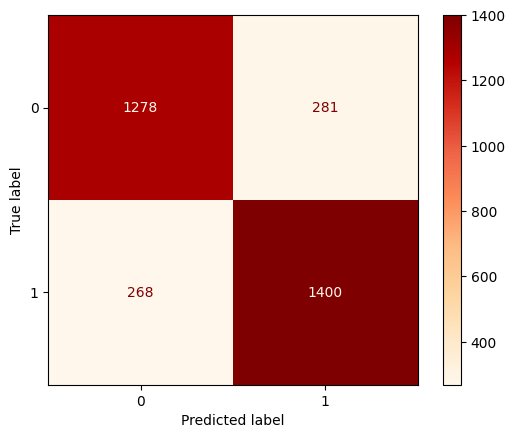

In [976]:
auc_xg = roc_auc_score(y_pred_xg, y_test)
acc_xg = accuracy_score(y_pred_xg, y_test)

print('AUC Score:', auc_xg.round(5))
print('Accuracy Score:', acc_xg.round(5))

# Assuming you have true labels in 'y_true' and predicted labels in 'y_pred'
cm = confusion_matrix(y_test, y_pred_xg)

# Create the ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(cm)

# Set the colormap to red and orange
cmap = plt.cm.get_cmap('OrRd')

# Plot the confusion matrix with the chosen colormap
cm_display.plot(cmap=cmap);

## Evaluating Profit/Loss

We can also look at the predicted probabilities for our test set and see how they compare to Bet365 odds. 

First we create a function to add predicted values and probabilities to our odds_win_test dataframe:

In [977]:
def add_preds_probs(odds_win_df, X_test, model):

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Get probabilities
    y_prob = model.predict_proba(X_test)

    # Convert probabilities to odds format
    y_prob = 1/y_prob

    # Get only probability of a win
    y_prob = [prob[1] for prob in y_prob]

    # Add to odds_win_df
    odds_win_df['model_odds'] = y_prob
    odds_win_df['pred_win'] = y_pred

    return odds_win_df

In [978]:
odds_win_df = add_preds_probs(odds_win_test, X_test, xg)

We can define functions for calculating profit/loss in different scenarios:

In [1019]:
# Function to calculate returns by betting on favourite:

def returns_from_fav(odds_win_df):
    # Filter the DataFrame for rows where the odds are less than or equal to 2.00
    filtered_df = odds_win_df[odds_win_df['odds'] <= 1.90].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: (row['odds'] * row['stake']) - row['stake'] if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total return from betting on favourite: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_fav(odds_win_df)

Total return from betting on favourite: £-194.42
Total staked: £8368.26


In [1020]:
def returns_from_model_pred_win(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a win
    filtered_df = odds_win_df[odds_win_df['pred_win'] == 1].copy()

    # Calculate the stake for each bet to ensure net winnings are always £1
    filtered_df['stake'] = 1 #/ (filtered_df['odds'] - 1)

    # Calculate the net profit (or loss) for each bet
    filtered_df['net_profit'] = filtered_df.apply(
        lambda row: (row['odds'] * row['stake']) - row['stake'] if row['won'] else -row['stake'], axis=1)

    # Calculate the total net profit and total staked
    total_net_profit = filtered_df['net_profit'].sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total net profit and total staked
    print(f"Total net profit from betting on player model predicted to win: £{total_net_profit:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

    return total_net_profit, total_staked

# Example usage
total_net_profit, total_staked = returns_from_model_pred_win(odds_win_df)


Total net profit from betting on player model predicted to win: £650.31
Total staked: £1681.00


In [1022]:
def returns_from_lower_odds(odds_win_df):
    # Filter the DataFrame for rows where the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[odds_win_df['model_odds'] < odds_win_df['odds']].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 #/ (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: (row['odds'] * row['stake']) - row['stake'] if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than bookmakers: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_lower_odds(odds_win_df)


Total returns from betting on players where model odds are lower than bookmakers: £634.91
Total staked: £1453.00


In [1025]:
# Function to calculate returns if we only bet on players where the model's odds 
# were lower than the bookmaker odds and who the model predicted would win:
   
def returns_lower_odds_and_pred_win(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a win and the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[(odds_win_df['pred_win'] == 1) & (odds_win_df['model_odds'] < odds_win_df['odds'])].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 #/ (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: (row['odds'] * row['stake']) - row['stake'] if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365 and model predicted to win: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_lower_odds_and_pred_win(odds_win_df)


Total returns from betting on players where model odds are lower than B365 and model predicted to win: £663.90
Total staked: £1248.00


In [1027]:
# Function to calculate returns if we only bet on players where the model's odds 
# were lower than the bookmaker odds and who the model predicted would lose:
   
def returns_lower_odds_and_pred_lose(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a loss and the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[(odds_win_df['pred_win'] == 0) & (odds_win_df['model_odds'] < odds_win_df['odds'])].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 #/ (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: (row['odds'] * row['stake']) - row['stake'] if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_lower_odds_and_pred_lose(odds_win_df)

Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £-28.99
Total staked: £205.00


## Evaluating on 2023 Results

First we load the dataset:

In [637]:
df_2023_orig = pd.read_excel(r'match_datasets_atp\2023.xlsx')
df_2023_new = pd.read_excel(r'2023 (3).xlsx')

In [638]:
df_2023_orig = df_2023_orig.sort_values('Date').reset_index(drop=True)
df_2023_new = df_2023_new.sort_values('Date').reset_index(drop=True)

In [642]:
# Find the difference in indices
indices_diff = df_2023_new.index.difference(df_2023_orig.index)

# Get the rows in df_2023_new that have these indices
df_2023 = df_2023_new.loc[indices_diff]

In [915]:
X_train_2023, X_test_2023, y_train_2023, y_test_2023, odds_win_train_2023, odds_win_test_2023 = combine_all_preprocessing(df_2023, player_df)

Number of changed names from player_df: 760
Number of unchanged names from player_df: 131
Number of all unique names in match_df: 150
Number of remaining unmatched names in match_df: 28


C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[new_col_name] = None
C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[new_col_name] = None
C:\Users\samke\AppData\Local\Temp\ipykernel_18012\532747439.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [ ]:
# Load model
xg = pickle.load(open('xg_model.pkl', 'rb'))

In [921]:
odds_win_test_2023.shape

(21, 2)

In [933]:
cols = df_train.columns.to_list()
cols.remove('won')
X_test_2023 = X_test_2023[cols]

In [984]:
X_test_2023.shape

(21, 104)

In [989]:
df_2023 = pd.read_excel('2023 (3).xlsx')

In [992]:
df_winners, df_losers = create_winner_loser_dfs(df_2023)
df_2023 = combine_winners_losers_dfs(df_winners, df_losers)

In [920]:
odds_win_df_2023 = add_preds_probs(odds_win_test_2023, X_test_2023, xg)

ValueError: Feature shape mismatch, expected: 48, got 104

In [993]:
df_2023

,player,opponent,Series,Surface,Round,date,player_rank,opp_rank,odds,rank_diff,pts_diff,won,rank_score,pts_score,straight_sets,ss_rank_score,ss_pts_score
0,Ajdukovic D.,Prizmic D.,ATP250,Clay,1st Round,2023-07-24,299.0,287.0,2.50,12.0,-10.0,0,-4927.0,-11435.0,-1,-4927.0,-4905.0
1,Albot R.,Van Rijthoven T.,ATP250,Hard,1st Round,2023-01-03,103.0,111.0,2.00,-8.0,43.0,0,-4907.0,-11488.0,-1,-4907.0,-4958.0
2,Albot R.,Krall L.,ATP250,Hard,1st Round,2023-02-08,123.0,NaN,1.05,NaN,NaN,1,NaN,NaN,0,0.0,0.0
3,Albot R.,Wolf J.J.,ATP250,Hard,2nd Round,2023-02-08,123.0,43.0,5.50,80.0,-479.0,0,-4995.0,-10966.0,-1,-4995.0,-4436.0
4,Albot R.,Verdasco F.,ATP250,Hard,1st Round,2023-02-14,113.0,133.0,1.57,-20.0,44.0,1,4935.0,11401.0,1,4935.0,4871.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5401,Zverev A.,Humbert U.,Masters 1000,Hard,2nd Round,2023-11-01,9.0,26.0,1.53,-17.0,2025.0,1,4932.0,9420.0,0,0.0,0.0
5402,Zverev A.,Tsitsipas S.,Masters 1000,Hard,3rd Round,2023-11-02,9.0,6.0,1.80,3.0,-895.0,0,-4918.0,-10550.0,-1,-4918.0,-4020.0
5403,Zverev A.,Alcaraz C.,Masters Cup,Hard,Round Robin,2023-11-13,8.0,2.0,2.75,6.0,-4870.0,1,4909.0,16315.0,0,0.0,0.0
5404,Zverev A.,Medvedev D.,Masters Cup,Hard,Round Robin,2023-11-15,8.0,3.0,2.75,5.0,-3615.0,0,-4920.0,-7830.0,-1,-4920.0,-1300.0


In [1005]:
returns_from_fav(match_df)


Total return from betting on favourite: £10194.00
Total staked: £27824.00


We can now look at returns for 2023 matches:

In [ ]:
returns_from_fav(odds_win_df_2023)
returns_from_model_pred_win(odds_win_df_2023)
returns_from_lower_odds(odds_win_df_2023)
returns_lower_odds_and_pred_win(odds_win_df_2023)
returns_lower_odds_and_pred_lose(odds_win_df_2023)

Total return from betting on favourite: £-17.45
Total staked: £2491.06
Total returns from betting on player model predicted to win: £-25.28
Total staked: £2503.38
Total returns from betting on players where model odds are lower than B365: £-34.53
Total staked: £636.45
Total returns from betting on players where model odds are lower than B365 and model predicted to win: £-42.98
Total staked: £560.41
Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £8.45
Total staked: £76.04
